In [1]:
from os.path import join, splitext, basename
import geopandas as gpd
from shapely.ops import transform
from glob import glob
import leafmap.foliumap as leafmap
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
save_dir = "../regions/shapes/"
os.makedirs(save_dir, exist_ok=True)

In [3]:
shapefile_path="/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/raw_data/raw_shapefile/delhi_ncr/ncr_region.shp"

df = gpd.read_file(shapefile_path).to_crs(epsg=4326)
# df['District'] = df['District'].str.replace('>', 'A')
# df['STATE'] = df['STATE'].str.replace('>', 'A')
# df['District'] = df['District'].str.replace('|', 'I')
#make it lowercase
# df['ADM1_EN']= df['ADM1_EN'].str.lower()
display(df.tail())


,District,STATE,REMARKS,State_LGD,DISTRICT_L,Shape_Leng,Shape_Area,geometry
25,PANIPAT,HARYANA,None,6,71,205738.448961,1.263801e+09,"POLYGON ((76.88899 29.52461, 76.88966 29.52461..."
26,REWARI,HARYANA,None,6,72,287206.335335,1.501531e+09,"MULTIPOLYGON (((76.43919 28.11075, 76.43964 28..."
27,ROHTAK,HARYANA,None,6,73,245463.495732,1.616225e+09,"POLYGON ((76.54193 29.09504, 76.54217 29.0945,..."
28,SONIPAT,HARYANA,None,6,75,280154.816359,2.112606e+09,"POLYGON ((76.61078 29.28917, 76.6128 29.28812,..."
29,CHARKHI DADRI,HARYANA,None,6,701,259526.538053,1.338809e+09,"POLYGON ((76.32302 28.81427, 76.32618 28.81382..."


In [10]:
dataframe=df[['geometry']]
dataframe

#save that dataframe to a geojson file
dataframe.to_file(join(save_dir, "delhi_ncr.geojson"), driver='GeoJSON')
#plot the dataframe
m = leafmap.Map()

m.add_basemap("OpenStreetMap")
m.add_gdf(dataframe, layer_name="ncr_region", style={"color": "blue", "weight": 2})
m

In [ ]:
#access the geometry of rajshahi
region='delhi_ncr'
rajshahi = dataframe[dataframe['ADM1_EN']==region]
rajshahi.reset_index(drop=True, inplace=True)
rajshahi

,ADM1_EN,geometry
0,sylhet,"MULTIPOLYGON (((91.30353 23.99673, 91.30344 23..."


In [29]:
rajshahi.to_file(join(save_dir,f"{region}.geojson"), driver='GeoJSON')
print("Saved to file")

Saved to file


In [30]:
m = leafmap.Map()
m.add_basemap("HYBRID")
m.add_gdf(rajshahi, layer_name=f"{region}")
display(m)

In [31]:
# ## print all up districts which comes underncr region
# ncr_districts = ['ALWAR','BHARATPUR']
# ncr_df = df[df['District'].isin(ncr_districts)]
# display(len(ncr_df))

In [32]:
# fig, ax = plt.subplots(figsize=(4, 4))
# ncr_df.plot(ax=ax, color="none", edgecolor="black", linewidth=0.5)

In [5]:
import geopandas as gpd

# Read the KML file
gdf = gpd.read_file("/home/patel_zeel/kiln_compass_24/raw_shapefiles/grids_lucknow.kml", driver="KML")

# Save as GeoJSON
gdf.to_file("grids_lucknow.geojson", driver="GeoJSON")


In [15]:
import geopandas as gpd

# Load shapefile and reproject to EPSG:4326 (WGS 84)
shapefile_path = "/home/patel_zeel/kiln_compass_24/raw_shapefiles/grids_lucknow.kml"
df = gpd.read_file(shapefile_path).to_crs(epsg=4326)

# Extract bounding box coordinates
df["xmin"], df["ymin"], df["xmax"], df["ymax"] = df.geometry.bounds.values.T

# Compute the four corner coordinates
df["top_left"] = list(zip(df["xmin"], df["ymax"]))
df["top_right"] = list(zip(df["xmax"], df["ymax"]))
df["bottom_left"] = list(zip(df["xmin"], df["ymin"]))
df["bottom_right"] = list(zip(df["xmax"], df["ymin"]))

# Display the last few rows
display(df[["top_left", "top_right", "bottom_left", "bottom_right"]])


,top_left,top_right,bottom_left,bottom_right
0,"(80.65, 26.610000000000003)","(80.66000000000001, 26.610000000000003)","(80.65, 26.6)","(80.66000000000001, 26.6)"
1,"(80.66000000000001, 26.610000000000003)","(80.67000000000002, 26.610000000000003)","(80.66000000000001, 26.6)","(80.67000000000002, 26.6)"
2,"(80.67, 26.610000000000003)","(80.68, 26.610000000000003)","(80.67, 26.6)","(80.68, 26.6)"
3,"(80.68, 26.610000000000003)","(80.69000000000001, 26.610000000000003)","(80.68, 26.6)","(80.69000000000001, 26.6)"
4,"(80.69000000000001, 26.610000000000003)","(80.70000000000002, 26.610000000000003)","(80.69000000000001, 26.6)","(80.70000000000002, 26.6)"
...,...,...,...,...
3595,"(81.2, 27.200000000000003)","(81.21000000000001, 27.200000000000003)","(81.2, 27.19)","(81.21000000000001, 27.19)"
3596,"(81.21000000000001, 27.200000000000003)","(81.22000000000001, 27.200000000000003)","(81.21000000000001, 27.19)","(81.22000000000001, 27.19)"
3597,"(81.22, 27.200000000000003)","(81.23, 27.200000000000003)","(81.22, 27.19)","(81.23, 27.19)"
3598,"(81.23, 27.200000000000003)","(81.24000000000001, 27.200000000000003)","(81.23, 27.19)","(81.24000000000001, 27.19)"


In [16]:
import geopandas as gpd

# Load the KML file
shapefile_path = "/home/patel_zeel/kiln_compass_24/raw_shapefiles/grids_lucknow.kml"
df = gpd.read_file(shapefile_path).to_crs(epsg=4326)  # Ensure WGS 84 (lat/lon) projection

# Get the overall bounding box of all grids
xmin, ymin, xmax, ymax = df.total_bounds  # Extract overall bounds

# Define the four corners
top_left = (xmin, ymax)
top_right = (xmax, ymax)
bottom_left = (xmin, ymin)
bottom_right = (xmax, ymin)

# Print or save as DataFrame
corners_df = gpd.GeoDataFrame(
    {
        "top_left": [top_left],
        "top_right": [top_right],
        "bottom_left": [bottom_left],
        "bottom_right": [bottom_right]
    }
)

print(corners_df)


                      top_left                                top_right  \
0  (80.65, 27.200000000000003)  (81.25000000000001, 27.200000000000003)   

     bottom_left               bottom_right  
0  (80.65, 26.6)  (81.25000000000001, 26.6)  


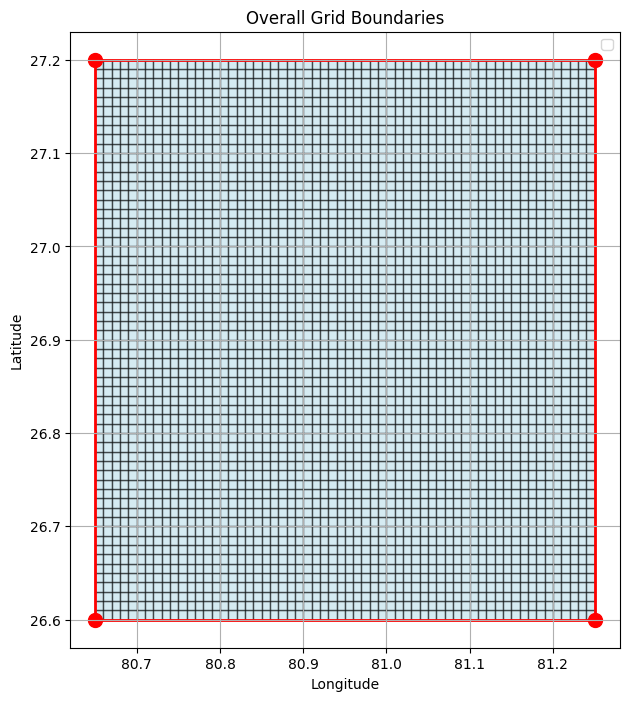

In [18]:
# Define bounding box as a polygon
from shapely.geometry import Polygon

bbox_polygon = Polygon([(xmin, ymin), (xmax, ymin), (xmax, ymax), (xmin, ymax)])

# Create a GeoDataFrame for the bounding box
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_polygon], crs="EPSG:4326")

# Plot the grids and bounding box
fig, ax = plt.subplots(figsize=(8, 8))
df.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.5, label="Grid Cells")
bbox_gdf.plot(ax=ax, edgecolor="red", linewidth=2, facecolor="none", label="Overall Bounding Box")

# Mark four corners
corners = [(xmin, ymax), (xmax, ymax), (xmin, ymin), (xmax, ymin)]
for x, y in corners:
    plt.scatter(x, y, color="red", marker="o", s=100)

# Labels
plt.title("Overall Grid Boundaries")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)

# Show plot
plt.show()
# What This Does:
# ✅ Plots the original grid system in blue
# ✅ Outlines the overall bounding box in red
# ✅ Marks the four corner points with red dots

# Try running this and let me know if you need adjustments! 🚀











In [20]:
import geopandas as gpd
import json
from shapely.geometry import Polygon

# Load the KML file
shapefile_path = "/home/patel_zeel/kiln_compass_24/raw_shapefiles/grids_lucknow.kml"
df = gpd.read_file(shapefile_path).to_crs(epsg=4326)  # Convert to EPSG:4326 (lat/lon)

# Get overall bounding box (xmin, ymin, xmax, ymax)
xmin, ymin, xmax, ymax = df.total_bounds

# Define bounding box as a Polygon
bbox_polygon = Polygon([(xmin, ymin), (xmax, ymin), (xmax, ymax), (xmin, ymax), (xmin, ymin)])

# Create a GeoDataFrame
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_polygon], crs="EPSG:4326")

# Save as GeoJSON
output_geojson = "bounding_box.geojson"
bbox_gdf.to_file(output_geojson, driver="GeoJSON")

print(f"GeoJSON saved at: {output_geojson}")


GeoJSON saved at: bounding_box.geojson
